In [ ]:
from google.colab import files
uploaded = files.upload()

Saving paddydataset.csv to paddydataset.csv


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [ ]:
df=pd.read_csv("paddydataset.csv")

In [ ]:
df.head()

,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   object 
 2   Variety                             2789 non-null   object 
 3   Soil Types                          2789 non-null   object 
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   object 
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days                         2789 no

In [ ]:
df.shape

(2789, 45)

In [ ]:
df.columns

Index(['Hectares ', 'Agriblock', 'Variety', 'Soil Types', 'Seedrate(in Kg)',
       'LP_Mainfield(in Tonnes)', 'Nursery', 'Nursery area (Cents)',
       'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb',
       'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days',
       'Pest_60Day(in ml)', '30DRain( in mm)', '30DAI(in mm)',
       '30_50DRain( in mm)', '30_50DAI(in mm)', '51_70DRain(in mm)',
       '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)',
       'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60',
       'Max temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90',
       'Min temp_D91_D120', 'Max temp_D91_D120',
       'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)',
       'Inst Wind Speed_D61_D90(in Knots)',
       'Inst Wind Speed_D91_D120(in Knots)', 'Wind Direction_D1_D30',
       'Wind Direction_D31_D60', 'Wind Direction_D61_D90',
       'Wind Direction_D91_D120', 'Relative Humidity_D1_D30',
       'Relative Humi

In [ ]:
df.isnull().sum()

,0
Hectares,0
Agriblock,0
Variety,0
Soil Types,0
Seedrate(in Kg),0
LP_Mainfield(in Tonnes),0
Nursery,0
Nursery area (Cents),0
LP_nurseryarea(in Tonnes),0
DAP_20days,0


In [ ]:
df.describe()

,Hectares,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,Weed28D_thiobencarb,Urea_40Days,Potassh_50Days,Micronutrients_70Days,...,Inst Wind Speed_D1_D30(in Knots),Inst Wind Speed_D31_D60(in Knots),Inst Wind Speed_D61_D90(in Knots),Inst Wind Speed_D91_D120(in Knots),Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
count,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,...,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000
mean,3.717461,92.936536,46.468268,74.349229,3.717461,148.698458,7.434923,100.854729,38.587250,55.761922,...,7.233417,8.512729,8.172822,9.449265,76.256938,87.594120,85.160272,83.859448,335.510936,22517.728935
std,1.437777,35.944420,17.972210,28.755536,1.437777,57.511072,2.875554,39.006885,14.924123,21.566652,...,2.566549,3.203679,1.993596,2.516664,8.001361,6.776736,3.492529,3.134875,134.314772,9199.661393
min,1.000000,25.000000,12.500000,20.000000,1.000000,40.000000,2.000000,27.130000,10.380000,15.000000,...,4.000000,4.000000,4.000000,6.000000,64.600000,78.000000,81.000000,79.000000,80.000000,5410.000000
25%,3.000000,75.000000,37.500000,60.000000,3.000000,120.000000,6.000000,81.390000,31.140000,45.000000,...,4.000000,6.000000,8.000000,6.000000,72.000000,80.000000,83.000000,81.000000,240.000000,16389.000000
50%,4.000000,100.000000,50.000000,80.000000,4.000000,160.000000,8.000000,108.520000,41.520000,60.000000,...,8.000000,10.000000,8.000000,10.000000,72.700000,91.000000,84.000000,84.000000,360.000000,24636.000000
75%,5.000000,125.000000,62.500000,100.000000,5.000000,200.000000,10.000000,135.650000,51.900000,75.000000,...,10.000000,12.000000,10.000000,12.000000,85.000000,95.000000,88.000000,87.000000,450.000000,31035.000000
max,6.000000,150.000000,75.000000,120.000000,6.000000,240.000000,12.000000,162.780000,62.280000,90.000000,...,10.000000,12.000000,10.000000,12.000000,88.500000,96.000000,92.000000,88.000000,600.000000,38814.000000


In [ ]:
df.duplicated().sum()

np.int64(451)

In [ ]:
encoder=LabelEncoder()
df["Agriblock"]=encoder.fit_transform(df["Agriblock"])
df["Variety"]=encoder.fit_transform(df["Variety"])
df["Soil Types"]=encoder.fit_transform(df["Soil Types"])
df["Nursery"]=encoder.fit_transform(df["Nursery"])
df["Wind Direction_D1_D30"]=encoder.fit_transform(df["Wind Direction_D1_D30"])
df["Wind Direction_D31_D60"]=encoder.fit_transform(df["Wind Direction_D31_D60"])
df["Wind Direction_D61_D90"]=encoder.fit_transform(df["Wind Direction_D61_D90"])
df["Wind Direction_D91_D120"]=encoder.fit_transform(df["Wind Direction_D91_D120"])

In [ ]:
X=df.drop(["Paddy yield(in Kg)"],axis=1)
y=df["Paddy yield(in Kg)"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model=LinearRegression()
print("\nLinearRegration Model Created")


LinearRegration Model Created


In [ ]:
model.fit(X_train,y_train)
print("\nModel Training Completed")


Model Training Completed


In [ ]:
coefficient=pd.DataFrame({
    "Features":X.columns,
    "Coefficient":model.coef_
})
coefficient


,Features,Coefficient
0,Hectares,0.018586
1,Agriblock,1.455124
2,Variety,8.873798
3,Soil Types,-16.511498
4,Seedrate(in Kg),0.464642
5,LP_Mainfield(in Tonnes),0.232321
6,Nursery,34.667769
7,Nursery area (Cents),0.371714
8,LP_nurseryarea(in Tonnes),0.018586
9,DAP_20days,0.743427


In [ ]:
predict=model.predict(X_test)

In [ ]:
comparison=pd.DataFrame({
    "Actual Profit":y_test.values,
    "Predicted Profit":predict
})

print("\nActual vs Predicted")
print(comparison.head(20))


Actual vs Predicted
    Actual Profit  Predicted Profit
0           25640      24321.148013
1           22512      24488.989941
2           25228      24352.103093
3           30575      30706.075166
4           17649      18012.473079
5           36690      37035.802517
6           11256      11486.255845
7           29415      30770.990589
8           23420      24246.528902
9           16230      17873.445433
10          24828      24158.938855
11          24200      24286.480244
12          30545      30832.525547
13          31815      30948.990199
14          11816      11533.286722
15          11446      11568.052728
16           5836       5272.461946
17          38508      36786.235763
18          30805      30754.479091
19          30575      30480.843058


In [ ]:
mae = mean_absolute_error(y_test, predict)
mse = mean_squared_error(y_test, predict)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, predict)

print("\nMODEL PERFORMANCE")
print("-"*40)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R2 Score :", r2)




MODEL PERFORMANCE
----------------------------------------
Mean Absolute Error : 703.2177874140234
Mean Squared Error : 869027.0367313332
Root Mean Squared Error : 932.2161963468202
R2 Score : 0.9892858141576918


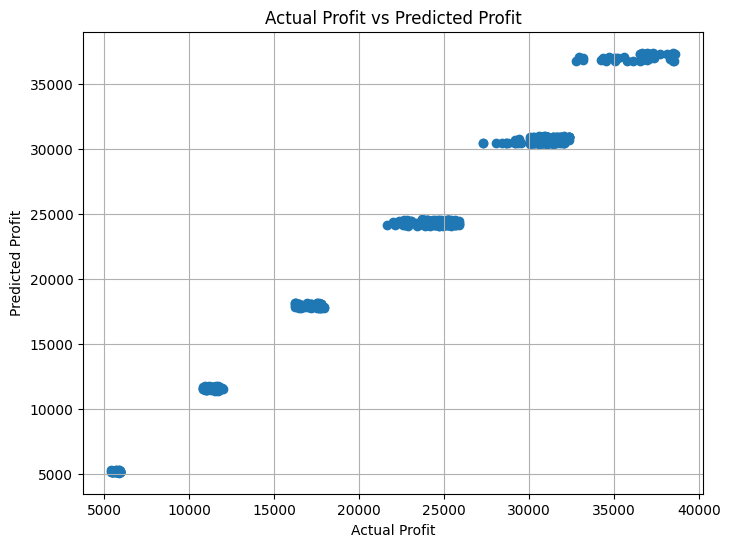

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predict
)

plt.xlabel("Actual Profit")

plt.ylabel("Predicted Profit")

plt.title("Actual Profit vs Predicted Profit")

plt.grid(True)

plt.show()


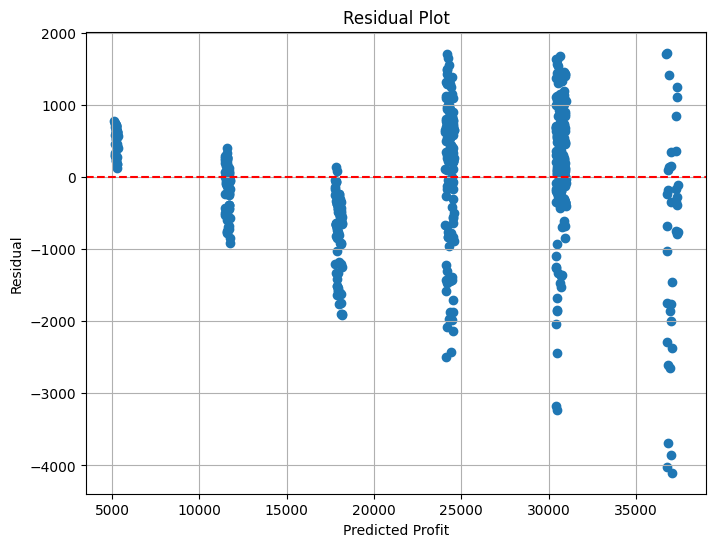

In [ ]:
residual = y_test - predict

plt.figure(figsize=(8,6))

plt.scatter(
    predict,
    residual
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Profit")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()


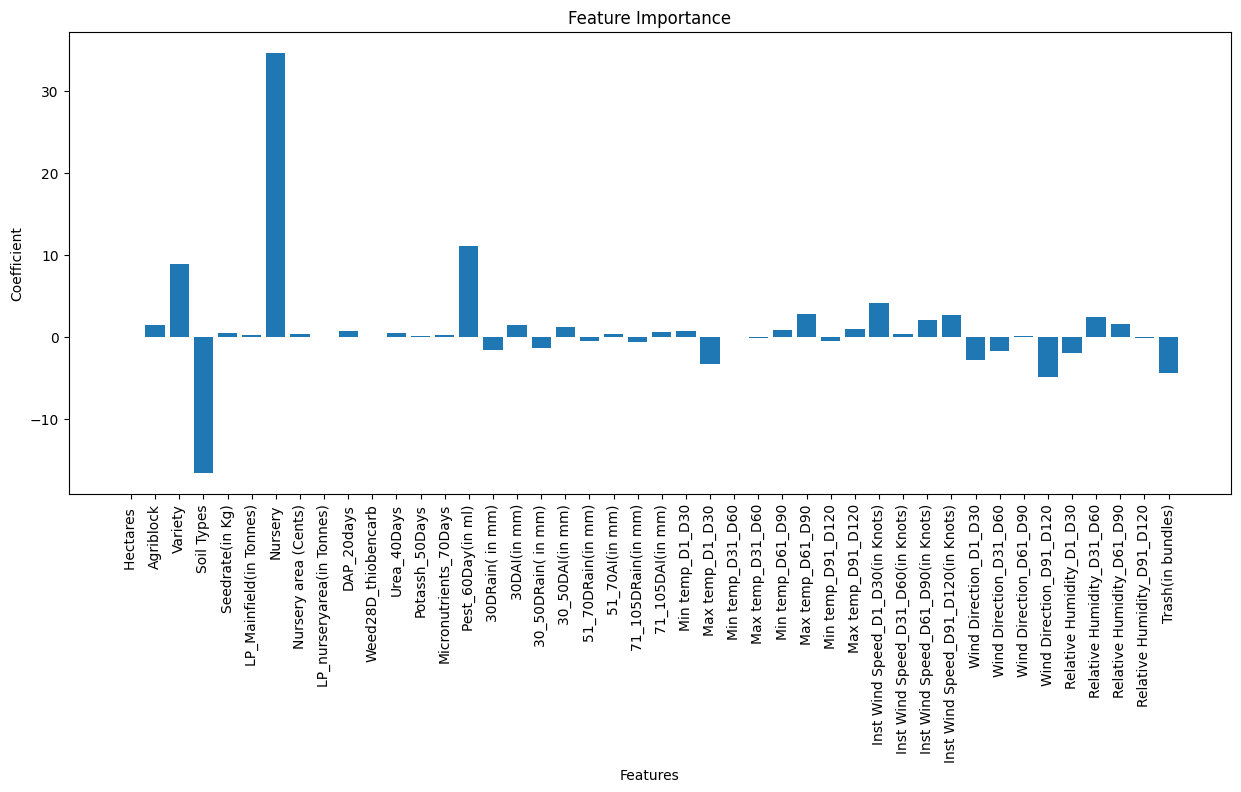

In [ ]:
plt.figure(figsize=(15,6))

plt.bar(
    coefficient["Features"],
    coefficient["Coefficient"]
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Coefficient")
plt.xticks(rotation=90)

plt.show()